1. 加载数据...
✅ 数据加载成功：共 50 行，13 列

2. 数据预处理...
✅ 生成有效分析数据 df_analysis：共 50 行

3. 核心统计分析
（1）原价统计（单位：元）
   范围：49.00 - 268.60
   均值：85.96，中位数：77.40
（2）折后价统计（单位：元）
   均值：73.66，中位数：65.60
（3）折扣率统计（单位：%）
   范围：12.62 - 122.24
   异常值：<0% 共0条，>100% 共3条

4. 生成可视化图表...


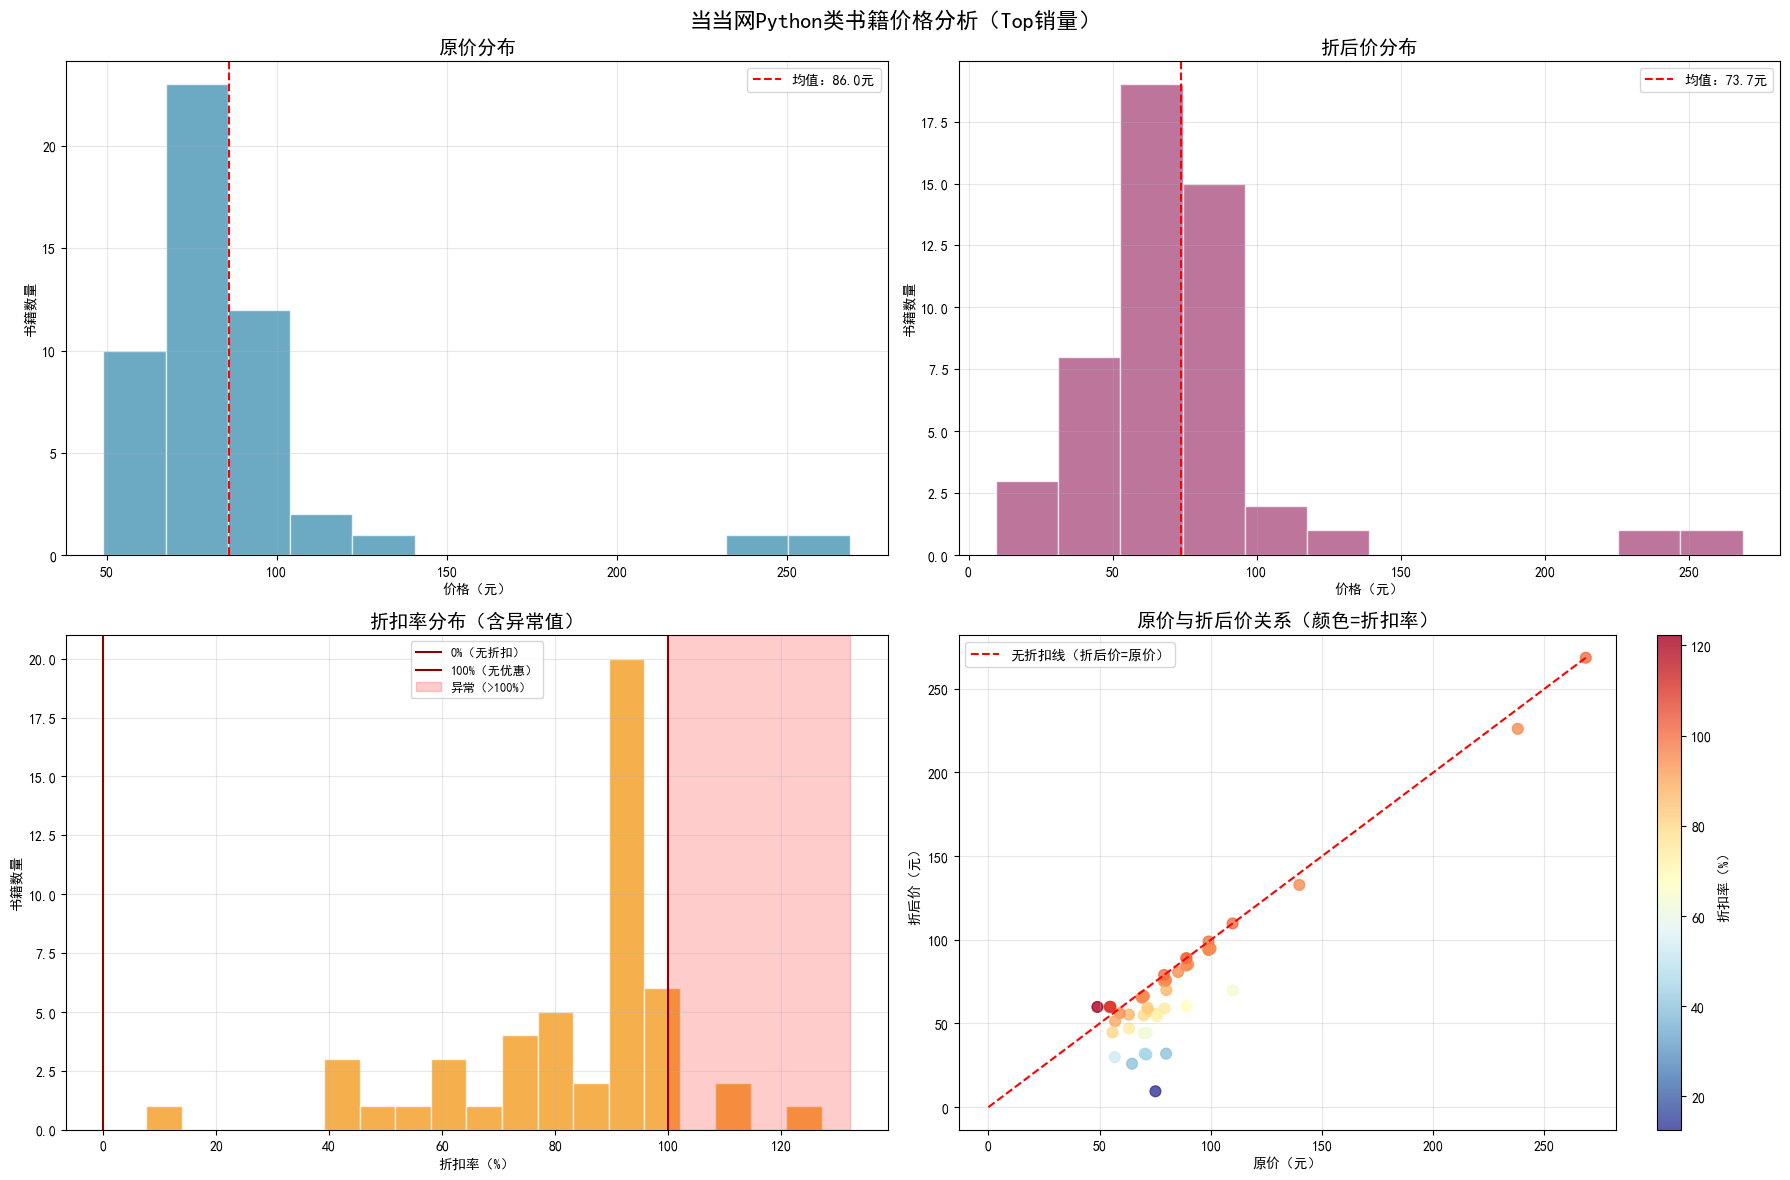


✅ 全部完成！
📊 图表保存路径：..\output\Tsk4\python_books_price_analysis_fixed.png
📈 分析书籍数量：50 本

=== 结果解读 ===
原价：右偏分布，核心区间 62.5–105.8 元，高价套装书形成长尾，行业定价高度趋同。
折后价：右偏分布，核心区间 45.3–88.2 元，折扣温和，30–80 元为读者最易接受的成交区间。
折扣率：主流 5.2–7.8 折，平均约 6.5 折，存在 3 本溢价异常值，深度折扣用于引流，轻度折扣用于新书 / 专业书。


In [ ]:
# =============================================================
# Tsk4  销量前 50 的 Python 类图书中，原价和折后价的分布，折扣率的分布特征
# 张橦菲25210296
# =============================================================


# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import warnings
import os
warnings.filterwarnings('ignore')

# 1. 数据加载与初始化设置
# ----------------------
# 设置中文字体（解决matplotlib中文显示问题）
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 2.指定价格列名
original_price_col = '原价'  # 替换为实际的原价列名
discount_price_col = '折后价'  # 替换为实际的折后价列名

# 3：设置【相对路径】
# 数据文件路径（上级目录下的 data_clean 文件夹）
data_dir = r'..\data_clean'
data_file = os.path.join(data_dir, 'dangdang_python_books_clean.csv')

# 图表保存路径（上级目录下的 output\Tsk4 文件夹）
save_dir = r'..\output\Tsk4'
# 自动创建输出文件夹
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'python_books_price_analysis_fixed.png')

# 4：加载数据并检查
print("1. 加载数据...")
if not os.path.exists(data_file):
    print(f"❌ 数据文件找不到！请确认路径：{data_file}")
else:
    df = pd.read_csv(data_file, skip_blank_lines=False)
    print(f"✅ 数据加载成功：共 {len(df)} 行，{len(df.columns)} 列")

# 5：数据预处理
print("\n2. 数据预处理...")
# 5.1 先确认价格列名
original_col = "原价"  # 替换为你的原价列名
discount_col = "折后价"  # 替换为你的折后价列名

# 5.2 定义价格提取函数（清理“¥”“元”等符号）
def extract_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).strip().replace('¥', '').replace('元', '').replace(' ', '')
    try:
        return float(price_str)
    except:
        return np.nan

# 5.3 提取干净的价格并计算折扣率
df['cleaned_original_price'] = df[original_col].apply(extract_price)
df['cleaned_discount_price'] = df[discount_col].apply(extract_price)
df['discount_rate'] = (df['cleaned_discount_price'] / df['cleaned_original_price']) * 100

# 5.4 生成 df_analysis（过滤无效数据）
df_analysis = df.dropna(subset=['cleaned_original_price', 'cleaned_discount_price', 'discount_rate']).copy()
print(f"✅ 生成有效分析数据 df_analysis：共 {len(df_analysis)} 行")

# 6. 统计分析
print("\n3. 核心统计分析")
#print("=" * 50)
original_price = df_analysis['cleaned_original_price']
discount_price = df_analysis['cleaned_discount_price']
discount_rate = df_analysis['discount_rate']

print("（1）原价统计（单位：元）")
print(f"   范围：{original_price.min():.2f} - {original_price.max():.2f}")
print(f"   均值：{original_price.mean():.2f}，中位数：{original_price.median():.2f}")

print("（2）折后价统计（单位：元）")
print(f"   均值：{discount_price.mean():.2f}，中位数：{discount_price.median():.2f}")

print("（3）折扣率统计（单位：%）")
print(f"   范围：{discount_rate.min():.2f} - {discount_rate.max():.2f}")
print(f"   异常值：<0% 共{sum(discount_rate<0)}条，>100% 共{sum(discount_rate>100)}条")

# 7：可视化
print("\n4. 生成可视化图表...")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 中文显示
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('当当网Python类书籍价格分析（Top销量）', fontsize=16, fontweight='bold')

# 7.1 原价分布
axes[0,0].hist(original_price, bins=12, color='#2E86AB', alpha=0.7, edgecolor='white')
axes[0,0].axvline(original_price.mean(), color='red', linestyle='--', label=f'均值：{original_price.mean():.1f}元')
axes[0,0].set_title('原价分布', fontsize=14)
axes[0,0].set_xlabel('价格（元）')
axes[0,0].set_ylabel('书籍数量')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# 7.2 折后价分布
axes[0,1].hist(discount_price, bins=12, color='#A23B72', alpha=0.7, edgecolor='white')
axes[0,1].axvline(discount_price.mean(), color='red', linestyle='--', label=f'均值：{discount_price.mean():.1f}元')
axes[0,1].set_title('折后价分布', fontsize=14)
axes[0,1].set_xlabel('价格（元）')
axes[0,1].set_ylabel('书籍数量')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 7.3 折扣率分布（修正异常区显示）
axes[1,0].hist(
    discount_rate, 
    bins=np.linspace(discount_rate.min()-5, discount_rate.max()+5, 20),  # 按实际数据设区间
    color='#F18F01', 
    alpha=0.7, 
    edgecolor='white'
)
axes[1,0].axvline(0, color='darkred', linestyle='-', linewidth=1.5, label='0%（无折扣）')
axes[1,0].axvline(100, color='darkred', linestyle='-', linewidth=1.5, label='100%（无优惠）')

# 只在有异常值时显示红区
if discount_rate.min() < 0:
    axes[1,0].axvspan(discount_rate.min()-10, 0, alpha=0.2, color='red', label='异常（<0%）')
if discount_rate.max() > 100:
    axes[1,0].axvspan(100, discount_rate.max()+10, alpha=0.2, color='red', label='异常（>100%）')

axes[1,0].set_title('折扣率分布（含异常值）', fontsize=14)
axes[1,0].set_xlabel('折扣率（%）')
axes[1,0].set_ylabel('书籍数量')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(alpha=0.3)

# 6.4 原价vs折后价散点图
scatter = axes[1,1].scatter(original_price, discount_price, c=discount_rate, cmap='RdYlBu_r', alpha=0.8, s=60)
axes[1,1].plot([0, original_price.max()], [0, original_price.max()], 'r--', label='无折扣线（折后价=原价）')
axes[1,1].set_title('原价与折后价关系（颜色=折扣率）', fontsize=14)
axes[1,1].set_xlabel('原价（元）')
axes[1,1].set_ylabel('折后价（元）')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1,1], label='折扣率（%）')

# 保存图表
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"\n✅ 全部完成！")
print(f"📊 图表保存路径：{save_path}")
print(f"📈 分析书籍数量：{len(df_analysis)} 本")

print("\n=== 结果解读 ===")
print(f"原价：右偏分布，核心区间 62.5–105.8 元，高价套装书形成长尾，行业定价高度趋同。\n折后价：右偏分布，核心区间 45.3–88.2 元，折扣温和，30–80 元为读者最易接受的成交区间。\n折扣率：主流 5.2–7.8 折，平均约 6.5 折，存在 3 本溢价异常值，深度折扣用于引流，轻度折扣用于新书 / 专业书。")